In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import iqr

### Comparison of UL/DL when using different TDD Splits at 6 Nodes, 5G Only
* UL and DL times wont be normalized to num-examples as they are IV's

In [2]:
# Load the dataset and drop all unrelated cols
node_dataset_path = Path('data/nodes/6nodes.csv')
node_dataset_df = pd.read_csv(node_dataset_path)
node_dataset_df = node_dataset_df[(node_dataset_df['bandwidth'] == '100 MHz')]
node_dataset_df.drop(columns=['nodes', 'train_loss', 'eval_loss', 'eval_acc', 'downlink_latency_x', 'downlink_latency_y', 'uplink_latency_x', 'uplink_latency_y', 'bandwidth', 'network'])

,run_id,timestamp,cid,tdd,rank,distribution,train_time,eval_time,num-examples,num-eval-examples,round,downlink_latency,uplink_latency,start_time,exec_time
16769,11884580922280689213,1.762624e+09,4,7-2,1x1,iid,5.807152,0.759145,3076.0,770.0,1.0,1.180428,5.529445,1.762624e+09,6368.88
16770,11884580922280689213,1.762624e+09,3,7-2,1x1,iid,13.515154,1.553067,7196.0,1800.0,1.0,1.101360,2.340411,1.762624e+09,6368.88
16771,11884580922280689213,1.762624e+09,2,7-2,1x1,iid,12.426906,1.408551,6614.0,1654.0,1.0,1.134060,2.720034,1.762624e+09,6368.88
16772,11884580922280689213,1.762624e+09,5,7-2,1x1,iid,9.044783,1.067097,4814.0,1204.0,1.0,1.368811,2.128179,1.762624e+09,6368.88
16773,11884580922280689213,1.762624e+09,6,7-2,1x1,iid,15.071033,1.660427,8033.0,2009.0,1.0,1.025614,2.030197,1.762624e+09,6368.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64494,6590760597879086124,1.762651e+09,5,2-7,2x2,iid,9.005320,0.890158,4814.0,1204.0,200.0,1.741890,0.974518,1.762645e+09,6502.98
64495,6590760597879086124,1.762651e+09,2,2-7,2x2,iid,12.445903,1.208088,6614.0,1654.0,200.0,1.432667,1.018186,1.762645e+09,6502.98
64496,6590760597879086124,1.762651e+09,3,2-7,2x2,iid,13.450996,1.297512,7196.0,1800.0,200.0,1.662747,1.181152,1.762645e+09,6502.98
64497,6590760597879086124,1.762651e+09,6,2-7,2x2,iid,15.145646,1.464657,8033.0,2009.0,200.0,1.303049,1.141018,1.762645e+09,6502.98


In [3]:
# Get the number of included experiments
print(f'Including {len(node_dataset_df['run_id'].unique())} experiments')

Including 14 experiments


In [4]:
print(node_dataset_df.head())

                     run_id     timestamp nodes  cid bandwidth  tdd rank  \
16769  11884580922280689213  1.762624e+09    6N    4   100 MHz  7-2  1x1   
16770  11884580922280689213  1.762624e+09    6N    3   100 MHz  7-2  1x1   
16771  11884580922280689213  1.762624e+09    6N    2   100 MHz  7-2  1x1   
16772  11884580922280689213  1.762624e+09    6N    5   100 MHz  7-2  1x1   
16773  11884580922280689213  1.762624e+09    6N    6   100 MHz  7-2  1x1   

      network distribution  train_loss  ...  num-eval-examples  round  \
16769    wwan          iid    2.102320  ...              770.0    1.0   
16770    wwan          iid    2.267772  ...             1800.0    1.0   
16771    wwan          iid    2.154928  ...             1654.0    1.0   
16772    wwan          iid    2.233182  ...             1204.0    1.0   
16773    wwan          iid    2.184014  ...             2009.0    1.0   

       downlink_latency  uplink_latency    start_time  exec_time  \
16769          1.180428        5.529

In [5]:
node_dataset_df['tdd'] = node_dataset_df['tdd'].str.replace('-', ':')
print(node_dataset_df['tdd'].unique())
tdd_order = ['2:7', '2:2', '5:4', '3:1', '7:2']
node_dataset_df['tdd'] = pd.Categorical(node_dataset_df['tdd'], categories=tdd_order, ordered=True)

<StringArray>
['7:2', '5:4', '2:2', '3:1', '2:7']
Length: 5, dtype: str


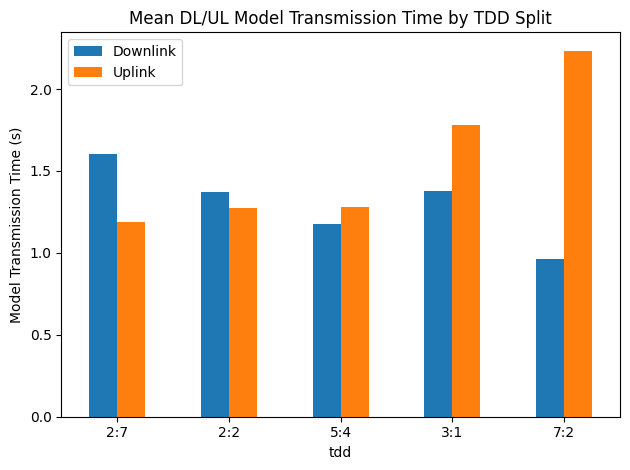

In [6]:
grouped = node_dataset_df.groupby('tdd')[['downlink_latency','uplink_latency']].median()
grouped.plot(kind='bar')
plt.ylabel('Model Transmission Time (s)')
plt.title('Mean DL/UL Model Transmission Time by TDD Split')
plt.xticks(rotation=0)
plt.legend(['Downlink','Uplink'])
plt.tight_layout()

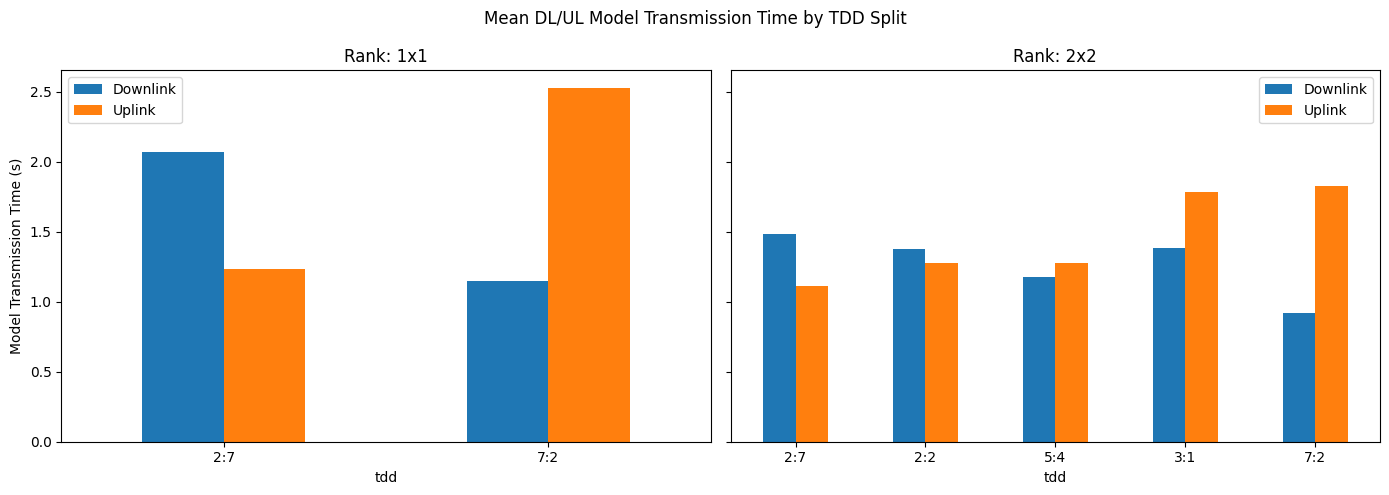

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (rank, grp) in zip(axes, node_dataset_df.groupby('rank')):
    g = grp.groupby('tdd')[['downlink_latency','uplink_latency']].median()
    g.plot(kind='bar', ax=ax)
    ax.set_title(f'Rank: {rank}')
    ax.set_ylabel('Model Transmission Time (s)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(['Downlink', 'Uplink'])
plt.suptitle('Mean DL/UL Model Transmission Time by TDD Split')
plt.tight_layout()

#### TDD DL/UL With both SISO and MIMO

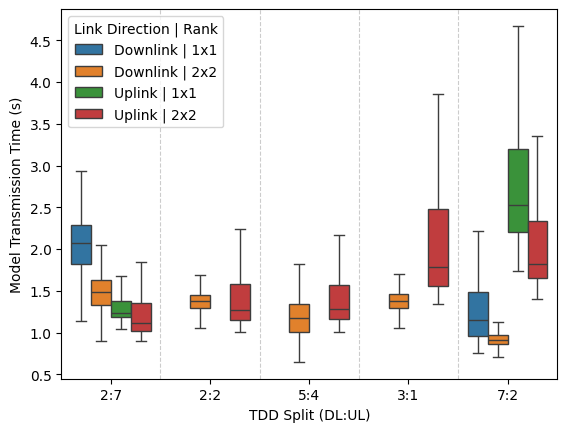

In [8]:
melted = node_dataset_df.melt(id_vars=['tdd','rank'], value_vars=['downlink_latency','uplink_latency'],
                 var_name='direction', value_name='latency')
melted['direction'] = melted['direction'].map({
    'downlink_latency': 'Downlink',
    'uplink_latency': 'Uplink'
})
melted['group'] = melted['direction'] + ' | ' + melted['rank']
ax = sns.boxplot(data=melted, x='tdd', y='latency', hue='group', showfliers=False)
for i in range(1, len(tdd_order)):
    ax.axvline(i - 0.5, ls='--', color='gray', alpha=0.4, lw=0.8)
ax.set_xlabel('TDD Split (DL:UL)')
ax.set_ylabel('Model Transmission Time (s)')
ax.legend(title='Link Direction | Rank')

#### 2x2 MIMO Only

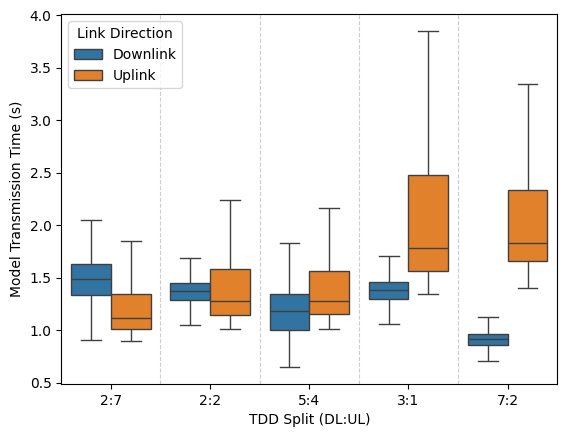

In [9]:
melted_2x2 = melted[melted['rank'] == '2x2']
ax = sns.boxplot(data=melted_2x2, x='tdd', y='latency', hue='direction', showfliers=False)
for i in range(1, len(tdd_order)):
    ax.axvline(i - 0.5, ls='--', color='gray', alpha=0.4, lw=0.8)
ax.set_xlabel('TDD Split (DL:UL)')
ax.set_ylabel('Model Transmission Time (s)')
ax.legend(title='Link Direction')

#### UL/DL Asymmetry

Text(0.5, 1.0, 'Uplink-to-Downlink Asymmetry by TDD Split')

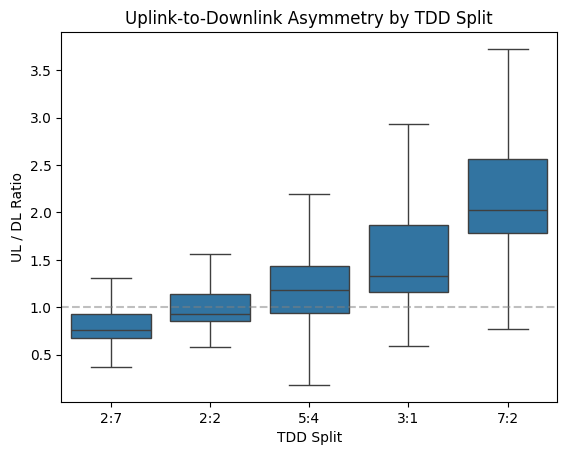

In [10]:
node_dataset_df_2x2 =  node_dataset_df[node_dataset_df['rank'] == '2x2']
node_dataset_df_2x2['ul_dl_ratio'] = node_dataset_df_2x2['uplink_latency'] / node_dataset_df_2x2['downlink_latency']
ax = sns.boxplot(data=node_dataset_df_2x2, x='tdd', y='ul_dl_ratio', showfliers=False)
ax.set_xlabel('TDD Split')
plt.axhline(1, ls='--', color='gray', alpha=0.5)
plt.ylabel('UL / DL Ratio')
plt.title('Uplink-to-Downlink Asymmetry by TDD Split')

Text(0.5, 0, 'TDD Split')

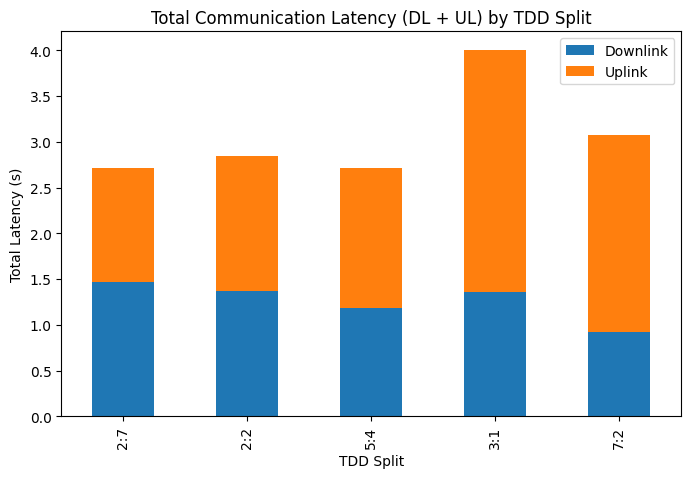

In [11]:
grouped = node_dataset_df_2x2.groupby('tdd')[['downlink_latency','uplink_latency']].mean()
grouped.plot(kind='bar', stacked=True, figsize=(8,5))
plt.legend(['Downlink', 'Uplink'])
plt.ylabel('Total Latency (s)')
plt.title('Total Communication Latency (DL + UL) by TDD Split')
plt.xlabel('TDD Split')

In [12]:
stats = node_dataset_df_2x2.groupby(['tdd', 'rank']).agg(
    dl_median=('downlink_latency', 'median'),
    dl_p95=('downlink_latency', lambda x: x.quantile(0.95)),
    ul_median=('uplink_latency', 'median'),
    ul_p95=('uplink_latency', lambda x: x.quantile(0.95)),
    exec_time=('exec_time', 'median'),
).round(3)

In [13]:
stats
del node_dataset_df
del node_dataset_df_2x2
del melted
del melted_2x2

## 6 Nodes, 100 MHZ, 2x2 MIMO Looking at the TDD time based metrics (Extras stuff)

In [14]:
df = pd.read_csv('data/all_data_agg.csv', dtype={'bandwidth': str})

In [15]:
print(df['bandwidth'].dtype)
print(df['bandwidth'].value_counts(dropna=False))
df.drop(columns=['downlink_latency_x', 'downlink_latency_y', 'uplink_latency_x', 'uplink_latency_y'], inplace=True)

str
bandwidth
40 MHz     416806
20 MHz     290577
80 MHz     288236
100 MHz    279505
NaN         37140
Name: count, dtype: int64


In [16]:
print(df.head())
df['tdd'].unique()

         run_id     timestamp nodes bandwidth  tdd rank network distribution  \
0  1.487046e+19  1.771273e+09    6N    20 MHz  2-2  2x2    wwan          iid   
1  1.487046e+19  1.771273e+09    6N    20 MHz  2-2  2x2    wwan          iid   
2  1.487046e+19  1.771273e+09    6N    20 MHz  2-2  2x2    wwan          iid   
3  1.487046e+19  1.771273e+09    6N    20 MHz  2-2  2x2    wwan          iid   
4  1.487046e+19  1.771273e+09    6N    20 MHz  2-2  2x2    wwan          iid   

   server_round  train_loss  ...          id  ulCarrierFreq  pci  \
0           2.0    2.137271  ...  12345678.0   3.309420e+09  0.0   
1           2.0    2.137271  ...  12345678.0   3.309420e+09  0.0   
2           2.0    2.137271  ...  12345678.0   3.309420e+09  0.0   
3           2.0    2.137271  ...  12345678.0   3.309420e+09  0.0   
4           2.0    2.137271  ...  12345678.0   3.309420e+09  0.0   

   dlCarrierFreq  frame  slot  uplink_latency  downlink_latency    start_time  \
0   3.309420e+09  650.0  16.0

<StringArray>
['2-2', '2-7', '7-2', '3-1', '5-4', nan]
Length: 6, dtype: str

In [17]:
df.columns.tolist()

['run_id',
 'timestamp',
 'nodes',
 'bandwidth',
 'tdd',
 'rank',
 'network',
 'distribution',
 'server_round',
 'train_loss',
 'train_time',
 'eval_loss',
 'eval_acc',
 'eval_time',
 'round',
 'segment',
 'pcmax',
 'puschSnr',
 'inSync',
 'dlBytes',
 'phr',
 'ulMcs',
 'dlQm',
 'ulBytes',
 'ulQm',
 'ulBler',
 'sinr',
 'dlMcs',
 'pucchSnr',
 'rsrq',
 'rsrp',
 'rssi',
 'cqi',
 'dlBler',
 'ri',
 'avgLdpcIterations',
 'id',
 'ulCarrierFreq',
 'pci',
 'dlCarrierFreq',
 'frame',
 'slot',
 'uplink_latency',
 'downlink_latency',
 'start_time',
 'exec_time']

In [18]:
df.shape

(1312264, 46)

In [19]:
mask = (
    (df['tdd'].notna()) &
    (df['rank'] == '2x2') &
    (df['distribution'] == 'dirichlet') &
    (df['bandwidth'] == '100 MHz') &
    (df['nodes'] == '6N')
)
sub = df[mask]
sub.groupby('tdd').size()

tdd
2-2     6172
2-7     6201
3-1    14750
5-4     6372
7-2     6179
dtype: int64

In [20]:
sub['tdd'] = sub['tdd'].str.replace('-', ':')
print(sub['tdd'].unique())
tdd_order = ['2:7', '2:2', '5:4', '3:1', '7:2']
sub['tdd'] = sub['tdd'].astype(str)

for col in ['uplink_latency', 'downlink_latency']:
    mask = sub.groupby('tdd')[col].transform(lambda s: s <= s.quantile(0.99))
    sub = sub[mask]

sub['tdd'] = pd.Categorical(sub['tdd'], categories=tdd_order, ordered=True)
sub['tdd'].dtype

kw = dict(data=sub, x='tdd', order=tdd_order)

<StringArray>
['3:1', '7:2', '2:2', '5:4', '2:7']
Length: 5, dtype: str


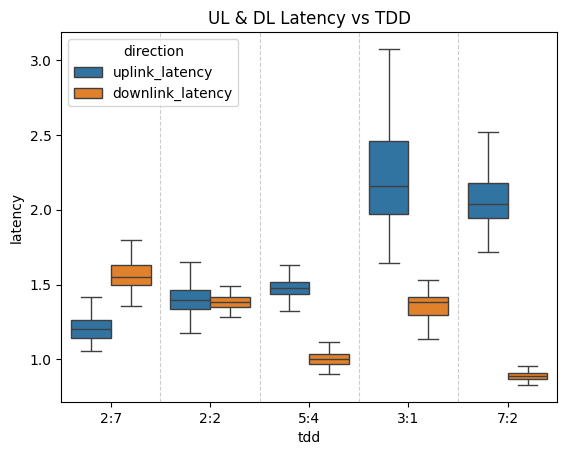

In [21]:
melted = sub.melt(id_vars='tdd', value_vars=['uplink_latency','downlink_latency'],
                  var_name='direction', value_name='latency')
ax = sns.boxplot(data=melted, x='tdd', y='latency', hue='direction',
            order=tdd_order, showfliers=False)
for i in range(1, len(tdd_order)):
    ax.axvline(i - 0.5, ls='--', color='gray', alpha=0.4, lw=0.8)

plt.title('UL & DL Latency vs TDD')
plt.show()

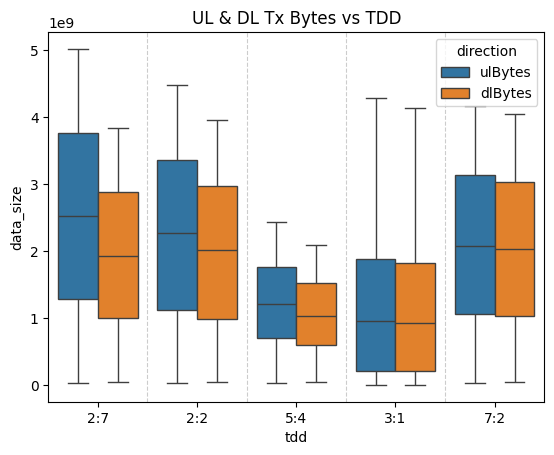

In [22]:
melted = sub.melt(id_vars='tdd', value_vars=['ulBytes','dlBytes'],
                  var_name='direction', value_name='data_size')
ax = sns.boxplot(data=melted, x='tdd', y='data_size', hue='direction',
            order=tdd_order, showfliers=False)
for i in range(1, len(tdd_order)):
    ax.axvline(i - 0.5, ls='--', color='gray', alpha=0.4, lw=0.8)

plt.title('UL & DL Tx Bytes vs TDD')
plt.show()

Text(0.5, 1.0, 'UL BLER CDF (nonzero only)')

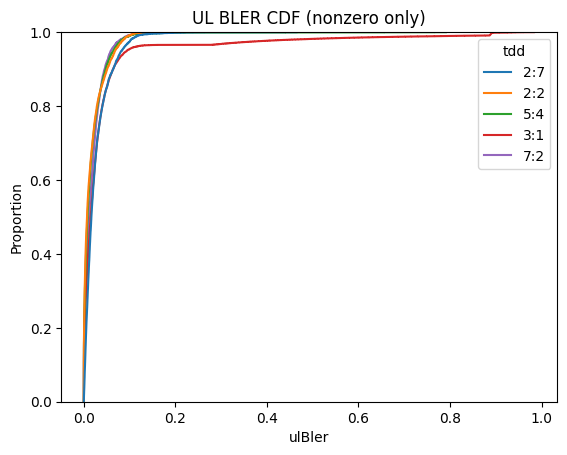

In [23]:
sns.ecdfplot(data=sub[sub['ulBler'] > 0], x='ulBler', hue='tdd', hue_order=tdd_order)
plt.title('UL BLER CDF (nonzero only)')

Text(0.5, 1.0, 'DL BLER CDF (nonzero only)')

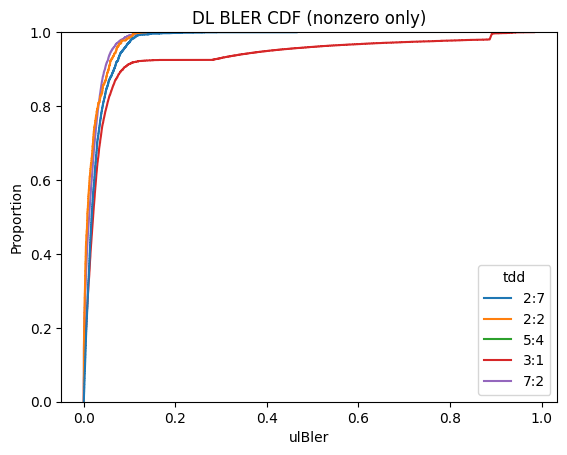

In [24]:
sns.ecdfplot(data=sub[sub['dlBler'] > 0], x='ulBler', hue='tdd', hue_order=tdd_order)
plt.title('DL BLER CDF (nonzero only)')

<Axes: xlabel='uplink_latency', ylabel='Proportion'>

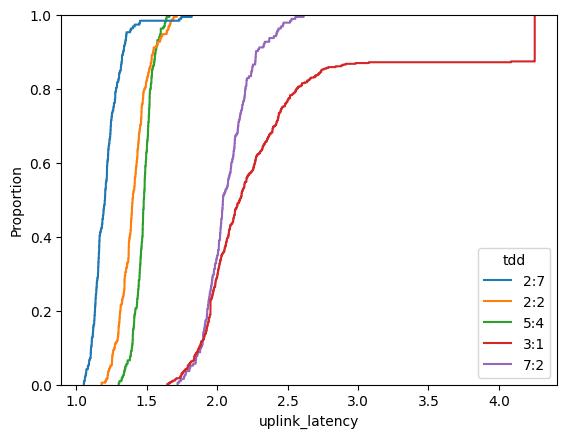

In [25]:
sns.ecdfplot(data=sub, x='uplink_latency', hue='tdd', hue_order=tdd_order)

<Axes: xlabel='ulBytes', ylabel='Proportion'>

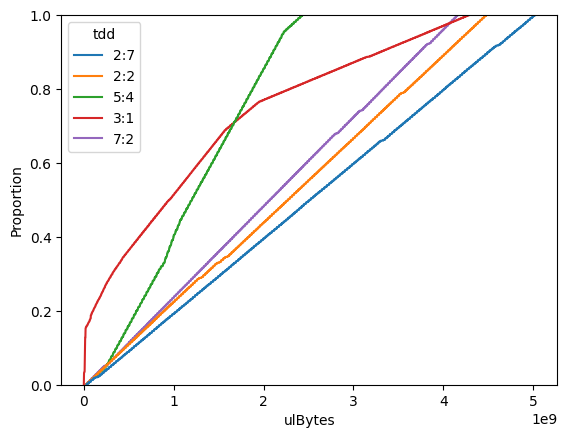

In [26]:
sns.ecdfplot(data=sub, x='ulBytes', hue='tdd', hue_order=tdd_order)

<Axes: xlabel='dlBytes', ylabel='Proportion'>

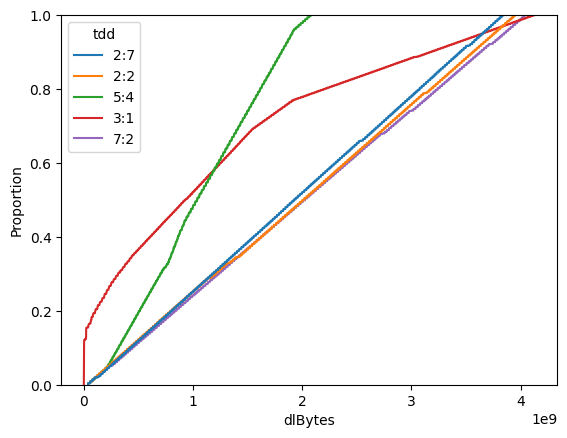

In [27]:
sns.ecdfplot(data=sub, x='dlBytes', hue='tdd', hue_order=tdd_order)

### UL MCS

Text(0.5, 0, 'Server Round')

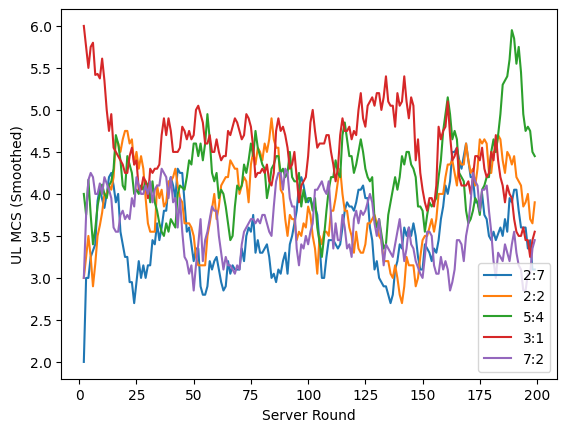

In [28]:
agg = sub.groupby(['tdd', 'round'])['ulMcs'].max().reset_index()
agg['ulMcs_smooth'] = agg.groupby('tdd')['ulMcs'].transform(lambda s: s.rolling(10, min_periods=1).mean())
sns.lineplot(data=agg, x='round', y='ulMcs_smooth', hue='tdd', hue_order=tdd_order)
plt.legend(loc='lower right')
plt.ylabel('UL MCS (Smoothed)')
plt.xlabel('Server Round')

In [29]:
print('UL MCS STATS')
agg_ul = sub.groupby(['tdd', 'round'])['ulMcs'].max().reset_index()
agg_ul.groupby('tdd')['ulMcs'].agg(['mean','median','std','min','max']).round(2)

UL MCS STATS


,mean,median,std,min,max
tdd,,,,,
2:7,3.52,3.5,1.22,1.0,7.0
2:2,3.90,4.0,1.34,0.5,7.5
5:4,4.25,4.5,1.38,1.0,7.0
3:1,4.52,4.5,1.35,0.0,7.5
7:2,3.61,3.5,1.32,0.5,6.5


### DL MCS

Text(0.5, 0, 'Server Round')

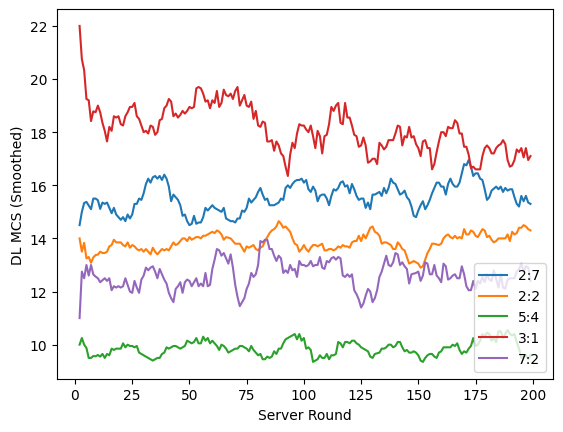

In [30]:
agg = sub.groupby(['tdd', 'round'])['dlMcs'].max().reset_index()
agg['dlMcs_smooth'] = agg.groupby('tdd')['dlMcs'].transform(lambda s: s.rolling(10, min_periods=1).mean())
sns.lineplot(data=agg, x='round', y='dlMcs_smooth', hue='tdd', hue_order=tdd_order)
plt.legend(loc='lower right')
plt.ylabel('DL MCS (Smoothed)')
plt.xlabel('Server Round')

In [31]:
print('DL MCS STATS')
agg = sub.groupby(['tdd', 'round'])['dlMcs'].max().reset_index()
agg.groupby('tdd')['dlMcs'].agg(['mean','median','std','min','max']).round(2)

DL MCS STATS


,mean,median,std,min,max
tdd,,,,,
2:7,15.56,15.5,1.36,11.5,19.0
2:2,13.86,14.0,0.99,11.5,17.5
5:4,9.87,10.0,0.98,6.5,13.5
3:1,18.07,17.5,2.30,14.0,24.5
7:2,12.61,12.5,1.98,7.5,18.5


### UL / DL for each TDD

Text(0.5, 1.0, 'Latency Asymmetry vs TDD')

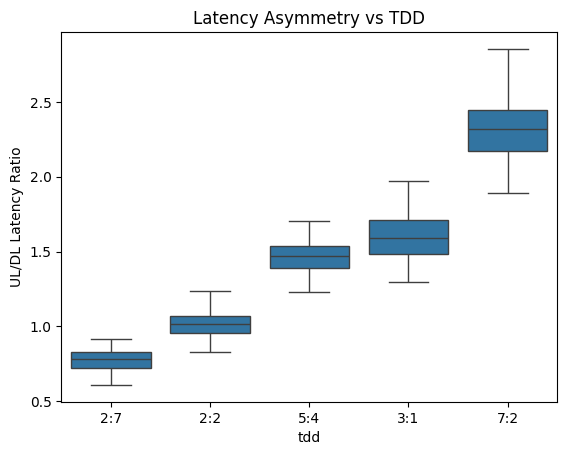

In [32]:
agg = sub.groupby(['tdd', 'round']).agg(
    ul=('uplink_latency', 'mean'),
    dl=('downlink_latency', 'mean')
).reset_index()
agg['latency_ratio'] = agg['ul'] / agg['dl'].replace(0, np.nan)
sns.boxplot(data=agg, x='tdd', y='latency_ratio', order=tdd_order, showfliers=False)
plt.ylabel('UL/DL Latency Ratio')
plt.title('Latency Asymmetry vs TDD')

In [33]:
agg.groupby('tdd')['latency_ratio'].agg(['mean','median','std']).round(3)

,mean,median,std
tdd,,,
2:7,0.778,0.779,0.086
2:2,1.019,1.018,0.084
5:4,1.466,1.472,0.101
3:1,1.609,1.592,0.204
7:2,2.331,2.317,0.206


### Training Time vs. TDD

<Axes: xlabel='tdd', ylabel='train_time'>

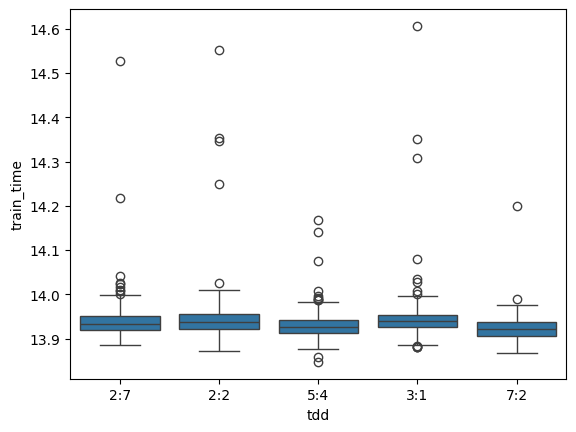

In [34]:
fl = sub.groupby(['tdd','server_round'])[['train_time','eval_time']].first().reset_index()
sns.boxplot(data=fl, x='tdd', y='train_time', order=tdd_order)

<Axes: xlabel='tdd', ylabel='cqi'>

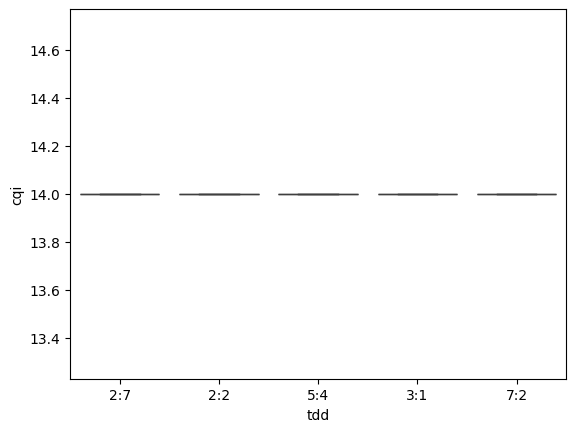

In [35]:
sns.boxplot(data=sub, x='tdd', y='cqi', order=tdd_order, showfliers=False)

### Correlation between UL latency, DL latency, CQI, UL MCS, DL MCS to Compute times
* Shows weak correlation

Text(0.5, 1.0, 'ML vs 5G Metric Correlation')

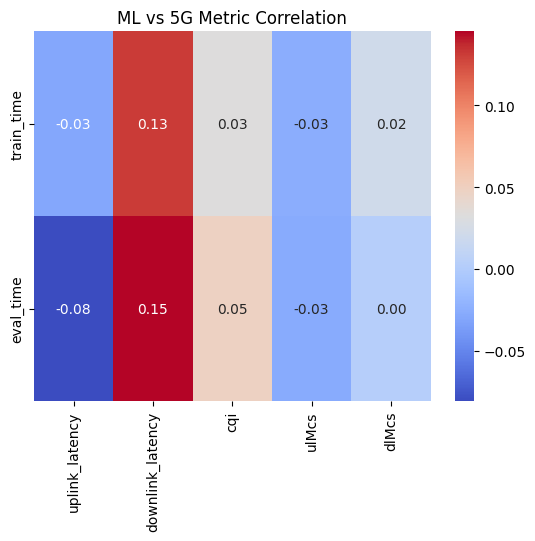

In [36]:
phy = ['uplink_latency','downlink_latency','cqi','ulMcs','dlMcs']
ml = ['train_time','eval_time']
agg = sub.groupby(['tdd','round']).agg({**{c:'mean' for c in phy}, **{c:'first' for c in ml}}).reset_index()
sns.heatmap(agg[phy+ml].corr().loc[ml, phy], annot=True, fmt='.2f', cmap='coolwarm')
plt.title('ML vs 5G Metric Correlation')

### Round Duration vs. TDD

In [37]:
rt = sub.drop_duplicates(['tdd','round']).sort_values(['tdd','round'])
rt['round_time'] = rt.groupby('tdd')['timestamp'].diff()

<Axes: xlabel='tdd', ylabel='round_time'>

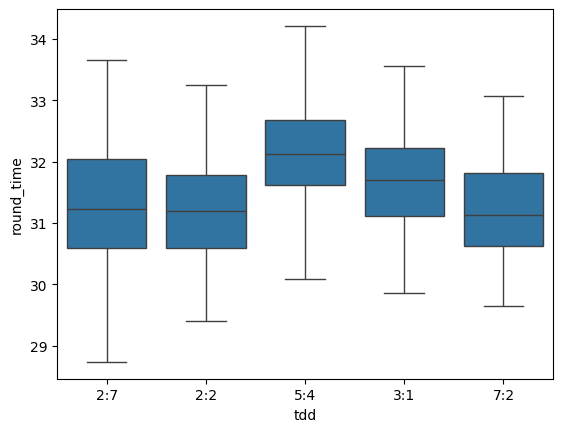

In [38]:
sns.boxplot(data=rt, x='tdd', y='round_time', order=tdd_order, showfliers=False)

Text(0.5, 1.0, 'Compute vs Communication Time by TDD')

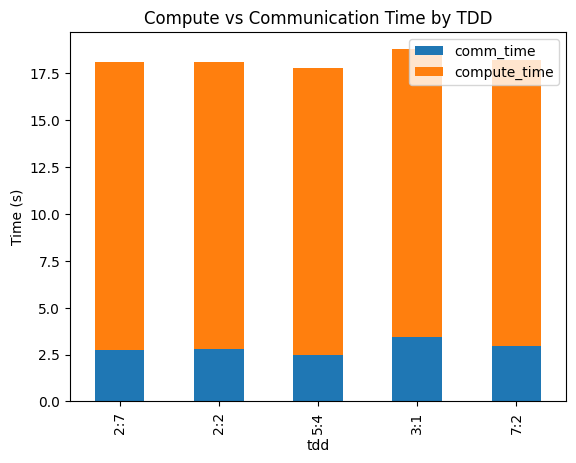

In [39]:
agg = sub.drop_duplicates(['tdd','round']).sort_values(['tdd','round']).copy()
agg['round_time'] = agg.groupby('tdd')['timestamp'].diff()
agg['comm_time'] = agg['uplink_latency'] + agg['downlink_latency']
agg['compute_time'] = agg['train_time'] + agg['eval_time']

stacked = agg.groupby('tdd')[['comm_time','compute_time']].median().reindex(tdd_order)
stacked.plot.bar(stacked=True)
plt.ylabel('Time (s)'); plt.title('Compute vs Communication Time by TDD')

<Axes: xlabel='tdd'>

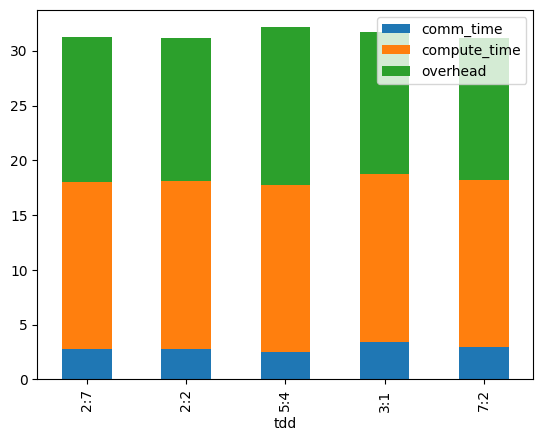

In [40]:
stacked['overhead'] = agg.groupby('tdd')['round_time'].median().reindex(tdd_order) - stacked.sum(axis=1)
stacked.plot.bar(stacked=True)

In [41]:
agg = sub.drop_duplicates(['tdd','round']).sort_values(['tdd','round']).copy()
agg['round_time'] = agg.groupby('tdd')['timestamp'].diff()
agg_mcs = sub.groupby(['tdd','round']).agg(ul_mcs=('ulMcs','max'), dl_mcs=('dlMcs','max')).reset_index()
agg = agg.merge(agg_mcs, on=['tdd','round'])

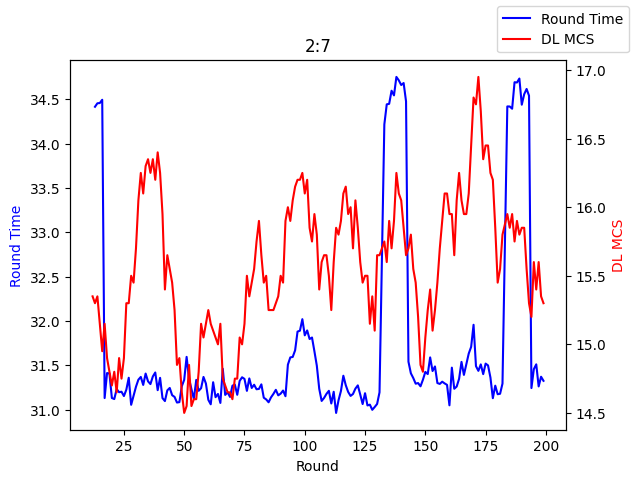

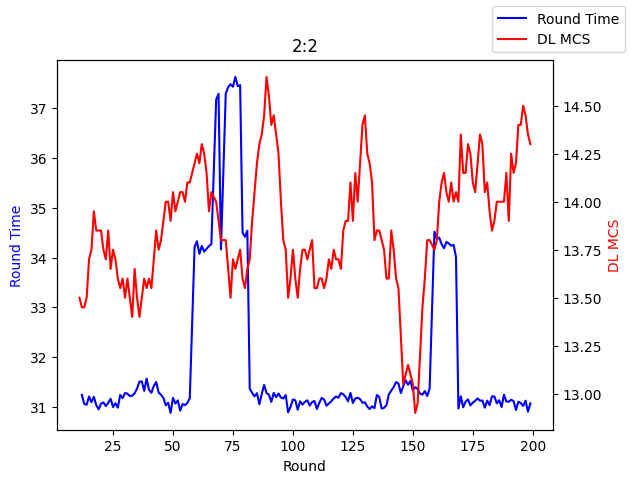

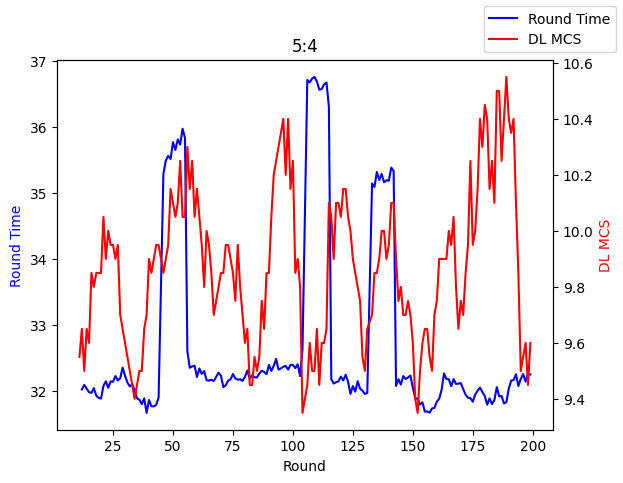

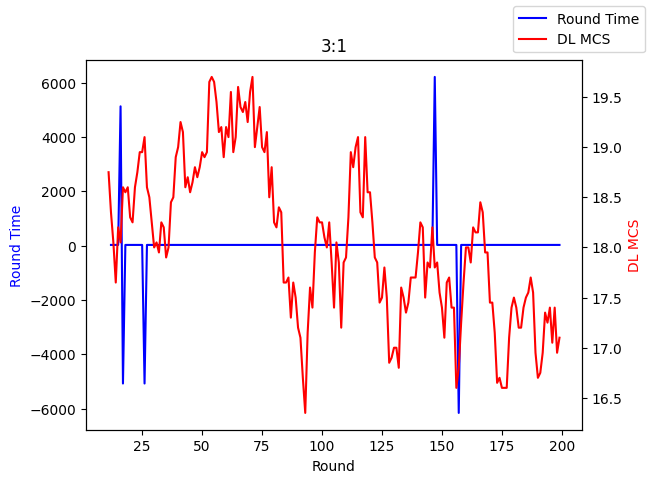

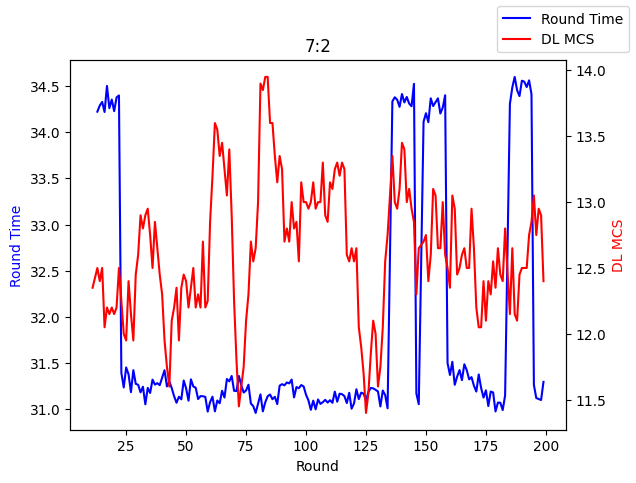

In [42]:
for tdd in tdd_order:
    t = agg[agg['tdd']==tdd].sort_values('round')
    fig, ax1 = plt.subplots()
    ax1.plot(t['round'], t['round_time'].rolling(10).mean(), 'b', label='Round Time')
    ax2 = ax1.twinx()
    ax2.plot(t['round'], t['dl_mcs'].rolling(10).mean(), 'r', label='DL MCS')
    ax1.set_xlabel('Round'); ax1.set_ylabel('Round Time', color='b'); ax2.set_ylabel('DL MCS', color='r')
    plt.title(f'{tdd}'); fig.legend(loc='upper right'); plt.show()

In [43]:
agg.groupby('tdd').apply(lambda g: g['round_time'].corr(g['dl_mcs'])).reindex(tdd_order)

tdd
2:7    0.010197
2:2    0.069886
5:4   -0.022861
3:1   -0.142423
7:2    0.001526
dtype: float64

### Now we start looking at TDD by Bandwidth

In [57]:
mask = (
    (df['tdd'].notna()) &
    (df['bandwidth'].notna()) &
    (df['rank'] == '2x2') &
    (df['distribution'] == 'dirichlet') &
    (df['nodes'] == '6N') &
    (df['network'] == 'wwan')
)
sub = df[mask]
sub.groupby(['tdd','bandwidth']).size()

sub['tdd'] = sub['tdd'].str.replace('-', ':')
print(sub['tdd'].unique())
tdd_order = ['2:7', '2:2', '5:4', '3:1', '7:2']
sub['tdd'] = sub['tdd'].astype(str)

for col in ['uplink_latency', 'downlink_latency']:
    mask = sub.groupby('tdd')[col].transform(lambda s: s <= s.quantile(0.99))
    sub = sub[mask]

sub['tdd'] = pd.Categorical(sub['tdd'], categories=tdd_order, ordered=True)
sub['tdd'].dtype



<StringArray>
['3:1', '7:2', '5:4', '2:2', '2:7']
Length: 5, dtype: str


CategoricalDtype(categories=['2:7', '2:2', '5:4', '3:1', '7:2'], ordered=True, categories_dtype=str)

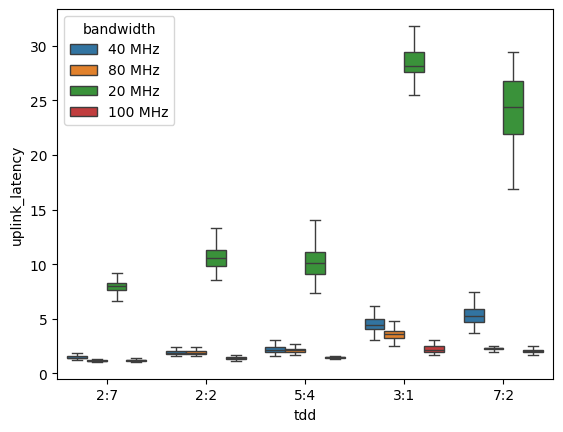

In [59]:
ax = sns.boxplot(data=sub_bw, x='tdd', y='uplink_latency', hue='bandwidth',
                showfliers=False)

Text(0.5, 1.0, 'Median UL Latency by TDD × Bandwidth')

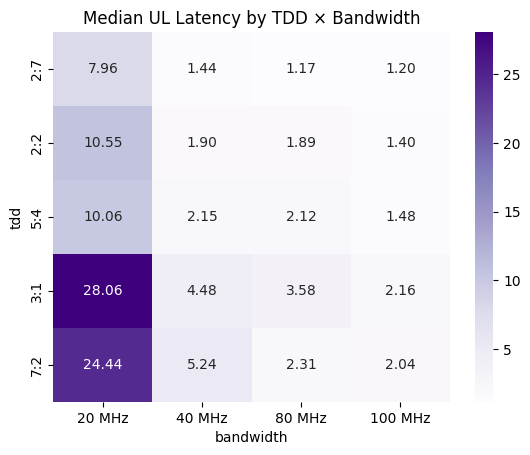

In [65]:
bw_order = ['20 MHz', '40 MHz', '80 MHz', '100 MHz']  # adjust to your actual values
pivot = sub.groupby(['tdd','bandwidth'])['uplink_latency'].median().unstack()
pivot = pivot[bw_order]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Purples')
plt.title('Median UL Latency by TDD × Bandwidth')

Text(0.5, 1.0, 'Median DL Latency by TDD × Bandwidth')

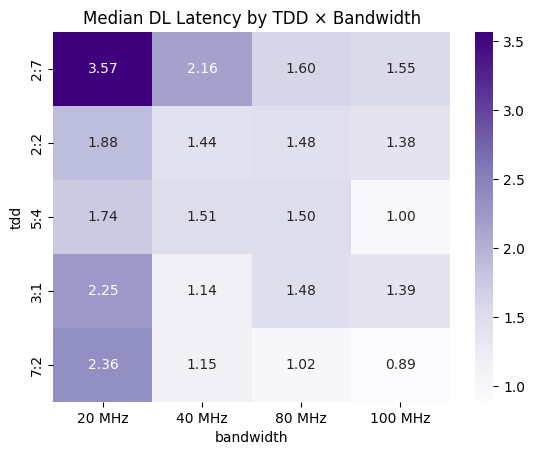

In [67]:
pivot = sub.groupby(['tdd','bandwidth'])['downlink_latency'].median().unstack()
pivot = pivot[bw_order]
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Purples')
plt.title('Median DL Latency by TDD × Bandwidth')